## Семинар: "Методы оптимизации"

In [1]:
from functools import partial

import numpy as np
import torch
from tqdm.auto import tqdm
from torch import nn
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.pyplot import cm
from matplotlib.colors import LogNorm
from matplotlib import animation
from mpl_toolkits import mplot3d
from matplotlib.gridspec import GridSpec
from torchvision import datasets, transforms
from IPython.display import HTML
%matplotlib inline
plt.rc('animation', html='html5')

На этом семинаре мы попробуем реализовать и сравнить различные методы оптимизации: SGD, Momentum, NAG, Adagrad, RMSProp, AdaDelta.

### Реализация методов

Для всех экспериментов подберите параметры так, чтобы метод сошелся к ближайшему локальному минимуму. Все методы следует запускать из одной и той же точки.

In [3]:
# https://github.com/dzlab/deepprojects/blob/master/visualization/Optimizers_in_Action.ipynb

def grid_samples(center=[0, 0], offset=5, size=100):
    range1 = np.linspace(center[0]-offset, center[0]+offset, size)
    range2 = np.linspace(center[1]-offset, center[1]+offset, size)
    return torch.from_numpy(np.stack(np.meshgrid(range1, range2))).float()


def mse(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1)


def msre(y, y_hat):
    return ((y - y_hat) ** 2).mean(axis=-1).sqrt()


def mae(y, y_hat):
    return ((y - y_hat).abs()).mean(axis=-1)


class LossAnimator:
    def __init__(self, X, y):
        self.X = X
        self.y = y
        self.size = len(X)

    def loss_func(self, W, loss):
        shape = W.shape
        return loss((self.X @ W.view(shape[0], -1)).T, self.y).view(shape[1:])

    def plot_loss_funcs(self, weights, fcts, titles, view=(20, 50)):
        num_fcts = len(fcts)
        fig = plt.figure(figsize=(7 * num_fcts,7))
        for i in range(num_fcts):
            loss = self.loss_func(weights, loss=fcts[i])
            ax = fig.add_subplot(1, num_fcts, i+1, projection='3d')
            ax.plot_surface(*weights, loss, cmap='viridis')
            ax.set_xlabel('w0'); ax.set_ylabel('w1'); ax.set_zlabel('Loss')
            ax.set_title(titles[i])
            ax.view_init(*view)

    def _init_animation(self, epochs, train_data):
        self.train_data = train_data
        self.epochs = epochs
        self.nmethods = len(train_data)

        weights = grid_samples(offset=5)

        max_loss = max([data['losses'].max() for data in train_data.values()])
        loss_curve = self.loss_func(weights, loss=mse)
        colors = cm.rainbow(np.linspace(0, 1, self.nmethods))


        self.fig = plt.figure(figsize=(14, 8))
        self.gs = GridSpec(2, 2, width_ratios=[1, 2.5])

        self.ax0 = self.fig.add_subplot(self.gs[0,0])
        self.lines0 = {
            name: self.ax0.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax0.scatter(self.X[:,0], self.y, c='orange', label='Ground truth')
        self.ax0.set_ylim(self.y.min(), self.y.max())
        self.ax0.set_title('Ground truth & Model', fontsize=16)
        self.ax0.legend(loc='lower right')

        self.ax1 = self.fig.add_subplot(self.gs[:,1], projection='3d')
        self.ax1.plot_surface(*weights, loss_curve-0.5, cmap='viridis', alpha=0.8)
        self.ax1.view_init(50, 70)
        self.lines1 = {
            name: self.ax1.plot3D([], [], [], c=c, marker='o', alpha=0.9, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax1.set_title('Loss', fontsize=16, pad=20)
        self.ax1.set_xlabel('w0')
        self.ax1.set_ylabel('w1')
        self.ax1.set_zlabel('Loss')
        self.ax1.legend()

        self.ax2 = self.fig.add_subplot(self.gs[1,0])
        self.lines2 = {
            name: self.ax2.plot([], [], c=c, label=name)[0]
            for name, c in zip(train_data.keys(), colors)
        }
        self.ax2.set_title('Loss', fontsize=16)
        self.ax2.set_ylabel('loss')
        self.ax2.set_ybound(0, max_loss)
        self.ax2.set_xlim(0, epochs)
        self.ax2.legend(loc='center right')

        self.fig.tight_layout()
        self.fig.subplots_adjust(top=0.85)

        plt.close()

        return self.fig

    def _animate(self, i):
        steps = np.arange(i+1)
        left = max(0, i-20)
        for name, data in self.train_data.items():
            # plot ground truth & model
            self.lines0[name].set_data(self.X[:, 0], self.X @ data['weights'][i])

            # plot loss (output of the sampling)
            self.lines1[name].set_data(data['weights'][left:i+1, 0], data['weights'][left:i+1, 1])
            self.lines1[name].set_3d_properties(data['losses'][left:i+1])

            self.lines2[name].set_data(steps, data['losses'][:i+1])

        self.fig.suptitle(f'Epoch: {i}/{self.epochs}', fontsize=22)

    def animate(self, epochs, train_data, step_skip=1):
        self._init_animation(epochs, train_data)
        anim = animation.FuncAnimation(self.fig, self._animate, frames=range(0, epochs, step_skip), interval=100 * step_skip)
        return HTML(anim.to_html5_video())

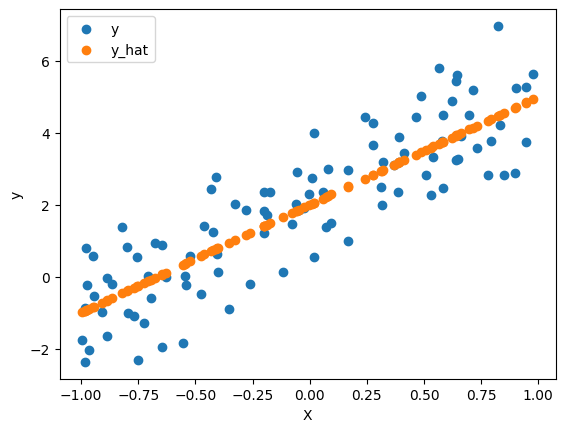

In [4]:
size = 100
X = torch.ones(size, 2)
X[:, 0].uniform_(-1., 1)

y_hat = 3 * X[:, 0] + 2
y = y_hat + torch.randn(size)

loss_animator = LossAnimator(X, y)

plt.scatter(loss_animator.X[:,0], loss_animator.y, label='y');
plt.scatter(loss_animator.X[:,0], y_hat, label='y_hat');
plt.xlabel('X')
plt.ylabel('y')
plt.legend()

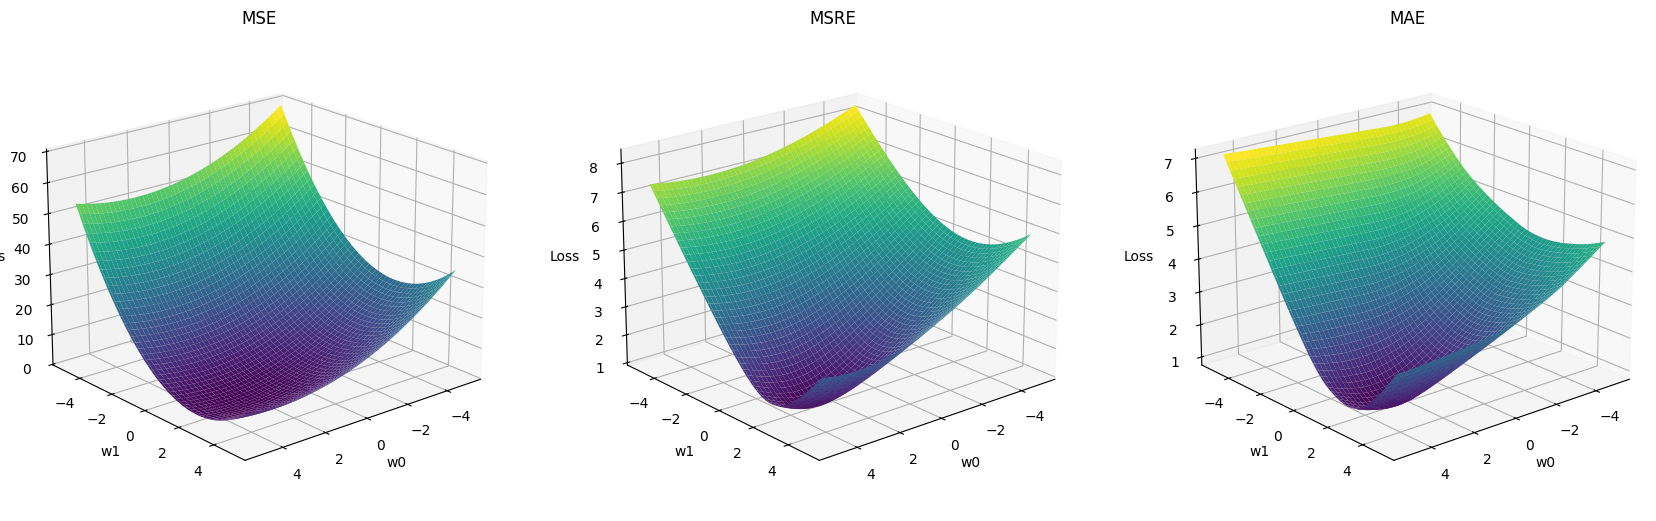

In [5]:
weights = grid_samples()
loss_animator.plot_loss_funcs(weights, [mse, msre, mae], ['MSE', 'MSRE', 'MAE'])

In [79]:
class Optimizer:
    def __init__(self, params):
        self.params = list(params)

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def pre_step(self):
        pass

    def step(self):
        pass

    def update_param(self, p):
        raise NotImplementedError()


In [7]:
def optimize_function(fn, optim, optim_args, start_point, num_iter = 50):
    weigths = nn.Parameter(torch.FloatTensor(start_point), requires_grad=True)

    optim = optim(params=[weigths], **optim_args)
    points = []
    losses = []
    for i in range(num_iter):
        if hasattr(optim, 'pre_step'):
            optim.pre_step()
        loss = fn(weigths)
        points.append(weigths.data.detach().clone())
        losses.append(loss.item())
        loss.backward()
        optim.step()
        optim.zero_grad()
    points = torch.stack(points, axis=0)
    losses = torch.FloatTensor(losses)
    return points, losses


In [8]:
def compare_optimizers(
    loss_animator,
    fn,
    optim_list,
    start_point,
    num_iter = 50,
    step_skip = 1
):
    data = {}
    loss_func = partial(loss_animator.loss_func, loss=fn)
    for name, optim, args in tqdm(optim_list):
        points, losses = optimize_function(loss_func, optim, args, start_point, num_iter)
        data[name] = {
            'weights': points,
            'losses': losses,
        }

    return loss_animator.animate(num_iter, data, step_skip=step_skip)

#### SGD
$$\theta_t = \theta_{t-1} - \eta \sum_{i_1, ..., i_k} \nabla_{\theta} J_{i} (\theta_{t-1})$$

In [9]:
class SGD(Optimizer):
    def __init__(self, params, lr=1e-2):
        super().__init__(params)
        self.lr = lr

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                p -= self.lr * p.grad


#### Momentum
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [10]:
class Momentum(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= self.prev_momentum[i]

#### Nesterov Accelerated Gradient (NAG)
$$\nu_t=\gamma \nu_{t-1} + \eta_t \nabla_{\theta} J_{i} (\theta_{t-1} - \gamma \nu_{t-1})$$
$$\theta_t = \theta_{t-1} - \nu_t$$

In [11]:
class NAG(Optimizer):
    def __init__(self, params, lr=1e-2, gamma=0.9):
        super().__init__(params)
        self.lr = lr
        self.gamma = gamma

        self.prev_momentum = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                prev_momentum = self.prev_momentum[i]
                self.prev_momentum[i] = self.gamma * prev_momentum + self.lr * p.grad
                p -= (1 + self.gamma) * self.prev_momentum[i] - self.gamma * prev_momentum

#### AdaGrad
$$G_t = \sum_{k=0}^t g_{k}^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [12]:
class AdaGrad(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2):
        super().__init__(params)
        self.epsilon = epsilon
        self.eta = eta

        self.G = [torch.zeros(p.shape) for p in self.params]

    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.G[i] += p.grad ** 2
                p -= self.eta * p.grad / torch.sqrt(self.G[i] + self.epsilon)

#### RMSProp
$$G_t = \gamma G_{t-1} + (1 - \gamma) g_t^2$$
$$\theta_{t} = \theta_{t-1} - \frac{\eta}{\sqrt{G_{t-1} + ϵ}} \cdot g_{t-1}$$

In [13]:
class RMSProp(Optimizer):
    def __init__(self, params, epsilon=1e-8, eta=1e-2, gamma=0.9):
        super().__init__(params)
        self.eta = eta
        self.epsilon = epsilon
        self.gamma = gamma

        self.G = [torch.zeros(p.shape) for p in self.params]


    def step(self):
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue

                self.G[i] = self.gamma * self.G[i] + (1 - self.gamma) * (p.grad ** 2)
                p -= self.eta / torch.sqrt(self.G[i] + self.epsilon) * p.grad

In [14]:
from functools import partial

points, losses = optimize_function(
    partial(loss_animator.loss_func, loss=mse),
    SGD,
     {'lr': 1e-2},
    start_point=[-4, -4],
    num_iter=100
)

In [15]:
compare_optimizers(
    loss_animator,
    mae,
    [
        ['SGD', SGD, {'lr': 1e-1}],
        ['Momentum', NAG, {'lr': 1e-1}],
        ['NAG', NAG, {'lr': 1e-1}],
        ['AdaGrad', AdaGrad, {'eta' : 1}],
        ['RMSProp', RMSProp, {'eta' : 1}],
    ],
    start_point=[-4, -4],
    num_iter=100
)

100%|██████████| 5/5 [00:00<00:00, 20.95it/s]


###  Домашнее задание: Обучение нейронной сети + Подбор шага

В этом задании вам нужно:
1) Реализовать Adam, AdamW и обучить сверточную нейросеть на MNIST. Сравнить графики обучения для SGD, Adam и AdamW. **(2 балла)**
2) Реализовать LinearLR и CosineAnnealingLR. Обучить сверточную нейросеть на MNIST с SGD, Adam, AdamW с LinearLR, CosineAnnealingLR. Сравните графики изменения loss-функции и точности (суммарно должно быть 9 экспериментов, 3 из которых покрываются пунктом 1). **(3 балла)**

Ссылки:
- https://arxiv.org/abs/1711.05101 (AdamW, статья)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.AdamW.html (AdamW, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.LinearLR.html (LinearLR, PyTorch)
- https://docs.pytorch.org/docs/stable/generated/torch.optim.lr_scheduler.CosineAnnealingLR.html (CosineAnnealingLR, PyTorch)

In [10]:
!wget www.di.ens.fr/~lelarge/MNIST.tar.gz
!tar -zxvf MNIST.tar.gz

"wget" �� ���� ����७��� ��� ���譥�
��������, �ᯮ��塞�� �ணࠬ��� ��� ������ 䠩���.
tar: Error opening archive: Failed to open 'MNIST.tar.gz'


In [11]:
transform = transforms.Compose([
   transforms.ToTensor(),
   transforms.Normalize((0.1307,), (0.3081,))
])

train_dataset = datasets.MNIST('.', train=True, download=True, transform=transform)
test_dataset = datasets.MNIST('.', train=False, transform=transform)

train_loader = torch.utils.data.DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = torch.utils.data.DataLoader(test_dataset, batch_size=32, shuffle=True)

In [12]:
import torch.nn.functional as F


class Net(nn.Module):
    def __init__(self):
        super().__init__()
        self.conv1 = nn.Conv2d(1,    16, 3, padding=1)
        self.conv2 = nn.Conv2d(16,  32, 3, padding=1)
        # self.conv3 = nn.Conv2d(32,  64, 3, padding=1)
        self.pool  = nn.MaxPool2d(2, 2)
        self.fc1   = nn.Linear(32 * 14 * 14, 256)
        self.fc2   = nn.Linear(256, 10)
        
    def forward(self, x):
        x = F.relu(self.conv1(x))
        x = self.pool(F.relu(self.conv2(x)))
        # x = self.pool(F.relu(self.conv3(x)))
        x = x.view(x.size(0), -1)
        x = F.relu(self.fc1(x))
        return self.fc2(x)


In [13]:
import time
import matplotlib.pyplot as plt
from IPython.display import display
import numpy as np

class MultiOptimizerAnimator:
    def __init__(self, test_loader, epochs, optimizers_list, title='Optimizer Comparison'):
        self.epochs = epochs
        self.optimizers_list = optimizers_list
        self.colors = plt.cm.Set1(np.linspace(0, 1, len(optimizers_list)))
        
        self.fig, (self.ax_loss, self.ax_acc) = plt.subplots(1, 2, figsize=(15, 6))
        self.fig.suptitle(title, fontsize=16)
        
        self.loss_data = {name: [] for name, _ in optimizers_list}
        self.acc_data = {name: [] for name, _ in optimizers_list}
        self.epoch_data = {name: [] for name, _ in optimizers_list}
        
        self.loss_lines = {}
        for i, (name, _) in enumerate(optimizers_list):
            line, = self.ax_loss.plot([], [], 'o-', color=self.colors[i], 
                                    linewidth=2, markersize=4, label=name)
            self.loss_lines[name] = line
        
        self.ax_loss.set_xlim(0, epochs)
        self.ax_loss.set_xlabel('Epoch')
        self.ax_loss.set_ylabel('Loss')
        self.ax_loss.set_title('Training Loss Comparison')
        self.ax_loss.grid(True, alpha=0.3)
        self.ax_loss.legend()
        
        self.acc_lines = {}
        for i, (name, _) in enumerate(optimizers_list):
            line, = self.ax_acc.plot([], [], 'o-', color=self.colors[i], 
                                   linewidth=2, markersize=4, label=name)
            self.acc_lines[name] = line
        
        self.ax_acc.set_xlim(0, epochs)
        self.ax_acc.set_ylim(80, 100)
        self.ax_acc.set_xlabel('Epoch')
        self.ax_acc.set_ylabel('Accuracy (%)')
        self.ax_acc.set_title('Test Accuracy Comparison')
        self.ax_acc.grid(True, alpha=0.3)
        self.ax_acc.legend()
        
        self.fig.tight_layout()

    def update(self, optimizer_name, epoch, loss, accuracy):
        self.epoch_data[optimizer_name].append(epoch)
        self.loss_data[optimizer_name].append(loss)
        self.acc_data[optimizer_name].append(accuracy)
        
        self.loss_lines[optimizer_name].set_data(
            self.epoch_data[optimizer_name], 
            self.loss_data[optimizer_name]
        )
        self.acc_lines[optimizer_name].set_data(
            self.epoch_data[optimizer_name], 
            self.acc_data[optimizer_name]
        )
        
        self.ax_loss.relim()
        self.ax_loss.autoscale_view()
        self.ax_acc.relim()
        self.ax_acc.autoscale_view()


def train_multiple_optimizers(optimizers_list, model_class, epochs=10):
    device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
    animator = MultiOptimizerAnimator(test_loader, epochs, optimizers_list, title="Optimizers Comparison")
    handle = display(animator.fig, display_id=True)
    results = {}
    
    for optimizer_name, optimizer_class in optimizers_list:
        print(f"\n--- Training with {optimizer_name} ---")
        

        model = model_class().to(device)
        
        criterion = nn.CrossEntropyLoss()
        optimizer = optimizer_class(model.parameters())
        
        for epoch in range(1, epochs + 1):
            model.train()
            running_loss = 0.0
            
            for images, labels in tqdm(train_loader, desc=f"Epoch {epoch}/{epochs}", leave=False):
                images, labels = images.to(device), labels.to(device)
                
                optimizer.zero_grad()
                outputs = model(images)
                loss = criterion(outputs, labels)
                loss.backward()
                optimizer.step()
                running_loss += loss.item()
            
            avg_loss = running_loss / len(train_loader)
            model.eval()
            correct, total = 0, 0
            with torch.no_grad():
                for images, labels in test_loader:
                    images, labels = images.to(device), labels.to(device)
                    outputs = model(images)
                    _, predicted = torch.max(outputs.data, 1)
                    total += labels.size(0)
                    correct += (predicted == labels).sum().item()
            
            accuracy = 100 * correct / total
            animator.update(optimizer_name, epoch, avg_loss, accuracy)
            handle.update(animator.fig)
            time.sleep(0.05)
        
        results[optimizer_name] = {
            'final_accuracy': accuracy,
            'final_loss': avg_loss,
            'loss_history': animator.loss_data[optimizer_name],
            'acc_history': animator.acc_data[optimizer_name]
        }
        
        print(f"Final Accuracy for {optimizer_name}: {accuracy:.2f}%")
    
    plt.close(animator.fig)

    return results

In [14]:
class SGD:
    def __init__(self, params, lr=1e-1):
        self.lr = lr
        self.params = list(params)

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def step(self):
        with torch.no_grad():
            for p in self.params:
                if p.grad is None:
                    continue
                p -= self.lr * p.grad

In [15]:
class Adam:
    def __init__(self, params, lr=1e-4, beta1=0.9, beta2=0.999, eps=1e-8):
        self.params = list(params)

        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2  
        self.eps = eps
        self.t = 0
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * p.grad
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (p.grad ** 2)

                m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[i] / (1 - self.beta2 ** self.t)
                
                p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)

In [16]:
class AdamW:
    def __init__(self, params, lr=1e-4, beta1=0.9, beta2=0.999, eps=1e-8, weight_decay=1e-2):
        self.params = list(params)

        self.lr = lr
        self.beta1 = beta1
        self.beta2 = beta2  
        self.eps = eps
        self.weight_decay = weight_decay
        self.t = 0
        self.m = [torch.zeros_like(p) for p in self.params]
        self.v = [torch.zeros_like(p) for p in self.params]

    def zero_grad(self):
        for param in self.params:
            if param.grad is not None:
                param.grad.detach_()
                param.grad.zero_()

    def step(self):
        self.t += 1
        with torch.no_grad():
            for i, p in enumerate(self.params):
                if p.grad is None:
                    continue
                self.m[i] = self.beta1 * self.m[i] + (1 - self.beta1) * p.grad
                self.v[i] = self.beta2 * self.v[i] + (1 - self.beta2) * (p.grad ** 2)

                m_hat = self.m[i] / (1 - self.beta1 ** self.t)
                v_hat = self.v[i] / (1 - self.beta2 ** self.t)
                
                p -= self.lr * m_hat / (torch.sqrt(v_hat) + self.eps)
                p -= self.lr * self.weight_decay * p


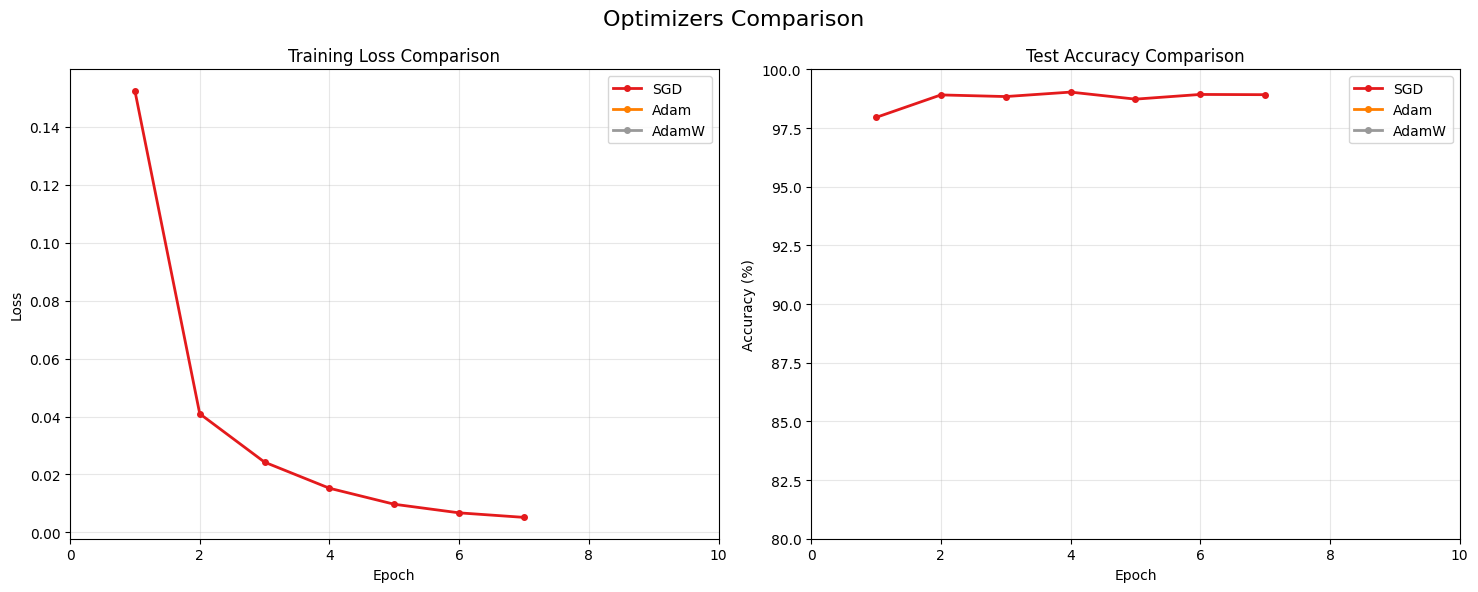


--- Training with SGD ---


Epoch 1/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 2/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 3/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 4/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 5/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 6/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 7/10:   0%|          | 0/1875 [00:00<?, ?it/s]

Epoch 8/10:   0%|          | 0/1875 [00:00<?, ?it/s]

In [ ]:
torch.manual_seed(42)

optimizers_list = [
    ('SGD', SGD),
    ('Adam', Adam),
    ('AdamW', AdamW)
]

results = train_multiple_optimizers(optimizers_list, Net, epochs=10)

В следующем блоке кода я пытался визуализировать ландшафт loss`а и сходимость на нем, поэтому в некоторых местах код может выгляжеть ужасно



In [ ]:
from torch.nn.utils import parameters_to_vector
from torch.nn.utils import vector_to_parameters
from scipy.interpolate import RegularGridInterpolator
import random

class LossLandscapeVisualizer:
    def __init__(self, model ,criterion, dataloader, device='cuda'):
        self.model  = model
        self.criterion = criterion
        self.dataloader = dataloader
        self.device = device
        self.model.to(self.device)
        self.initial_params = None
        self.final_params = None

    def save_initial_params(self):
        self.initial_params = self.get_params_vector()

    def save_final_params(self):
        self.final_params = self.get_params_vector()
    
    def get_params_vector(self):
        params = []
        for param in self.model.parameters():
            params.append(param.data.cpu().view(-1))
        return torch.cat(params)    
    
    def set_params_vector(self, params_vector):
        start_idx = 0
        for param in self.model.parameters():
            end_idx = start_idx + param.numel()
            param_data = params_vector[start_idx:end_idx].view(param.size()).to(self.device)
            start_idx = end_idx

    # def linear_interpolation(self, alpha):
    #     if self.initial_params is None or self.final_params is None:
    #         raise ValueError("Ты чо не сохранил состояния?")
    #     return (1 - alpha) * self.initial_params + alpha * self.final_params
    
    def evaluate_loss(self, params_vector, max_batches=10):
        orig_params = self.get_params_vector()
        
        try:
            self.set_params_vector(params_vector)
            self.model.eval()
            
            total_loss = 0.0
            total_samples = 0
            
            with torch.no_grad():
                for batch_idx, batch in enumerate(self.dataloader):
                    if batch_idx >= max_batches:
                        break
                        
                    if len(batch) == 2:
                        inputs, targets = batch
                    else:
                        inputs = batch[0]
                        targets = batch[1] if len(batch) > 1 else None
                    
                    inputs = inputs.to(self.device)
                    if targets is not None:
                        targets = targets.to(self.device)
                    
                    outputs = self.model(inputs)
                    
                    if targets is not None:
                        loss = self.criterion(outputs, targets)
                    else:
                        loss = outputs.mean()

                    total_loss += loss.item() * inputs.size(0)
                    total_samples += inputs.size(0)
                    
            return total_loss / total_samples if total_samples > 0 else total_loss
            
        finally:
            self.set_params_vector(orig_params)

    def plot_1d_landscape(self, num_points=100):
        alphas = np.linspace(0, 1, num_points)
        losses = []
        
        print("Вычисление 1D ландшафта...")
        for alpha in tqdm(alphas):
            params = self.linear_interpolation(alpha)
            loss = self.evaluate_loss(params)
            losses.append(loss)
        
        plt.figure(figsize=(10, 6))
        plt.plot(alphas, losses, 'b-', linewidth=2)
        plt.xlabel('α')
        plt.ylabel('Loss')
        plt.title("1D Loss Landscape")
        plt.grid(True, alpha=0.3)
        

        plt.axvline(x=0, color='r', linestyle='--', alpha=0.7, label='Начальная точка')
        plt.axvline(x=1, color='g', linestyle='--', alpha=0.7, label='Конечная точка')
        plt.legend()
        
        plt.tight_layout()
        plt.show()
        
        return alphas, losses

    def get_directions(self, seed=None):
        if seed is not None:
            torch.manual_seed(seed)
        d1 = torch.randn_like(self.initial_params)
        d1 = d1 / torch.norm(d1)
        
        d2 = torch.randn_like(self.initial_params)
        d2 = d2 - torch.dot(d2, d1) * d1
        d2 = d2 / torch.norm(d2)
        self.direction1 = d1
        self.direction2 = d2
        return self.direction1, self.direction2

    def set_start_from_xy(self, x, y):
        vec = self.initial_params + float(x)*self.direction1 + float(y)*self.direction2
        self.initial_params = vec.detach().to(self.device)

    def plot_2d_results(self, X, Y, Z, trajectories=None, zoom=False, title_suffix="", zoom_padding=0.1):

        X = np.asarray(X)
        Y = np.asarray(Y)
        Z = np.asarray(Z)

        x_coords = np.unique(X[0, :])
        y_coords = np.unique(Y[:, 0])
        interp = RegularGridInterpolator((y_coords, x_coords), Z, method='linear',
                                        bounds_error=False, fill_value=np.nan)

        fig2d = plt.figure(figsize=(15, 10))
        ax1 = fig2d.add_subplot(1, 1, 1)
        contour = ax1.contour(X, Y, Z, levels=15, colors='black', alpha=0.6)
        ax1.clabel(contour, inline=True, fontsize=8, fmt='%.2f')
        contourf = ax1.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
        ax1.set_xlabel('Direction 1')
        ax1.set_ylabel('Direction 2')
        ax1.set_title(f'2D Loss Landscape - Trajectory Comparison{title_suffix}')
        plt.colorbar(contourf, ax=ax1, label='Loss')
        ax1.grid(True, alpha=0.3)

        fig3d = plt.figure(figsize=(15, 10))
        ax3 = fig3d.add_subplot(1, 1, 1, projection='3d')
        surf = ax3.plot_surface(X, Y, Z, cmap='plasma', alpha=0.9,
                                linewidth=0, antialiased=True)
        ax3.set_xlabel('Direction 1')
        ax3.set_ylabel('Direction 2')
        ax3.set_title(f'2D Loss Landscape - 3D Surface{title_suffix}')
        plt.colorbar(surf, ax=ax3, label='Loss', shrink=0.6)
        ax3.view_init(elev=30, azim=45)

        if trajectories is not None and len(trajectories) > 0:
            colors = plt.cm.jet(np.linspace(0, 1, len(trajectories)))

            first_traj = next(iter(trajectories.values()))
            if len(first_traj) > 0:
                start_x, start_y = first_traj[0]
                ax1.plot(start_x, start_y, 'go', markersize=12, label='Start', markeredgecolor='k', zorder=10)
                
                start_z = interp((start_y, start_x))
                if not np.isnan(start_z):
                    ax3.scatter(start_x, start_y, start_z, c='g', s=80, marker='o', label='Start', edgecolors='k', zorder=10)

            for i, (name, trajectory) in enumerate(trajectories.items()):
                if not trajectory: continue 

                color = colors[i]
                traj_arr = np.asarray([(t[0], t[1]) for t in trajectory], dtype=float)
                traj_x, traj_y = traj_arr[:, 0], traj_arr[:, 1]
                final_points_x = []
                final_points_y = []
                pts = np.column_stack([traj_y, traj_x])
                traj_z = interp(pts)
                
                valid = ~np.isnan(traj_z)
                if np.any(valid):

                    tx, ty, tz = traj_x[valid], traj_y[valid], traj_z[valid]
                    final_points_x.append(tx[-1])
                    final_points_y.append(ty[-1])

                    ax1.plot(tx, ty, '-', color=color, linewidth=2.5, label=f'{name} Path')
                    ax1.plot(tx[-1], ty[-1], 'o', color=color, markersize=10, markeredgecolor='k', label=f'{name} End')
                    ax3.plot(tx, ty, tz, '-', color=color, linewidth=2.5, label=f'{name} Path')
                    ax3.scatter(tx[-1], ty[-1], tz[-1], c=[color], s=60, marker='o', edgecolors='k', label=f'{name} End')
                else:
                    ax1.plot(traj_x, traj_y, '--', color=color, linewidth=2.5, label=f'{name} Path (out of bounds)')
            
            ax1.legend()
            ax3.legend()

        plt.tight_layout()
        plt.show()
        if zoom and final_points_x:
            min_x, max_x = min(final_points_x), max(final_points_x)
            min_y, max_y = min(final_points_y), max(final_points_y)
            
            padding_x = (max_x - min_x) * zoom_padding if (max_x - min_x) > 1e-6 else zoom_padding
            padding_y = (max_y - min_y) * zoom_padding if (max_y - min_y) > 1e-6 else zoom_padding
            
            zoom_xlim = [min_x - padding_x, max_x + padding_x]
            zoom_ylim = [min_y - padding_y, max_y + padding_y]

            fig_zoom, ax_zoom = plt.subplots(figsize=(12, 12))
            
            ax_zoom.contour(X, Y, Z, levels=15, colors='black', alpha=0.6)
            ax_zoom.contourf(X, Y, Z, levels=50, cmap='viridis', alpha=0.8)
            
            for i, (name, trajectory) in enumerate(trajectories.items()):
                color = colors[i]
                traj_arr = np.asarray([(t[0], t[1]) for t in trajectory], dtype=float)
                ax_zoom.plot(traj_arr[:, 0], traj_arr[:, 1], '-', color=color, linewidth=2.5, label=f'{name} Path')
                ax_zoom.plot(traj_arr[-1][0], traj_arr[-1][1], 'o', color=color, markersize=10, markeredgecolor='k')
                
            ax_zoom.set_xlim(zoom_xlim)
            ax_zoom.set_ylim(zoom_ylim)
            
            ax_zoom.set_xlabel('Direction 1')
            ax_zoom.set_ylabel('Direction 2')
            ax_zoom.set_title('Zoomed View of Convergence Area')
            ax_zoom.legend()
            ax_zoom.grid(True, alpha=0.4)
            plt.show()

    def _interpolate_z(self, X, Y, Z, x, y):
        from scipy.interpolate import griddata
        points = np.column_stack([X.ravel(), Y.ravel()])
        values = Z.ravel()
        return griddata(points, values, (x, y), method='linear')


    

    def plot_2d_landscape_with_skip(self, trajectory, grid_size=30, skip=2, max_batches=10):
        if self.initial_params is None:
            raise ValueError("Сначала сохраните начальное состояние!")
        device = self.device if hasattr(self, "device") else ("cuda" if torch.cuda.is_available() else "cpu")
        direction1 = self.direction1.to(device)
        direction2 = self.direction2.to(device)
        initial_params = self.initial_params.to(device)
    
        x = np.linspace(-1, 1, grid_size)
        y = np.linspace(-1, 1, grid_size)
        X, Y = np.meshgrid(x, y)
        Z = np.full_like(X, np.nan)
        
        
        computed_points = 0
        for i in tqdm(range(0, grid_size, skip), desc="Rows"):
            for j in range(0, grid_size, skip):
                params = (initial_params + 
                        X[i, j] * direction1 + 
                        Y[i, j] * direction2)
                
                Z[i, j] = self.evaluate_loss(params, max_batches)
                computed_points += 1
        print("Интерполяция пропущенных точек...")
        Z = self.interpolate_missing_points(Z, skip)
        
        
        self.plot_2d_results(X, Y, Z, trajectories=trajectory, zoom=True)
        return X, Y, Z

    def interpolate_missing_points(self, Z, skip):
        from scipy import interpolate
        x = np.arange(Z.shape[1])
        y = np.arange(Z.shape[0])
        mask = ~np.isnan(Z)
        
        if np.any(mask):
            points = np.column_stack(np.where(mask))
            values = Z[mask]
            
            interp = interpolate.LinearNDInterpolator(points, values)
            Y_coords, X_coords = np.meshgrid(x, y)
            coords = np.column_stack([X_coords.ravel(), Y_coords.ravel()])
            
            Z_interpolated = interp(coords).reshape(Z.shape)
            Z_filled = np.where(mask, Z, Z_interpolated)
            return Z_filled
        else:
            return Z


def training(model, train_loader, direction1, direction2, initial_params, optimizer_name, epochs=20):
    model = model.to("cuda")
    match optimizer_name:
        case "adam":
            optimizer = Adam(model.parameters())
        case "adamw":
            optimizer = AdamW(model.parameters())
        case "sgd":
            optimizer = SGD(model.parameters())
    criterion = nn.CrossEntropyLoss()
    direction1 = direction1.to("cuda")
    direction2 = direction2.to("cuda")
    initial_params = initial_params.to("cuda")
    step = 0
    trajectory = []
    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            data, target = data.to("cuda"), target.to("cuda")
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()

            with torch.no_grad():
                theta_curr = parameters_to_vector(model.parameters()).detach()
                d = theta_curr - initial_params
                x = float(torch.dot(d, direction1).cpu().item())
                y = float(torch.dot(d, direction2).cpu().item())
                trajectory.append((x, y, step))
            step += 1
    return model, trajectory

def set_global_seed(seed):

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False


def demo_loss_landscape():
    set_global_seed(1234)
    model_adamw = Net()
    criterion = nn.CrossEntropyLoss()
    visualizer = LossLandscapeVisualizer(model_adamw, criterion, train_loader, device='cuda')
    
    visualizer.save_initial_params()
    direction1, direction2 = visualizer.get_directions(seed=42)
    
    grid_center_params = visualizer.get_params_vector()

    x_start, y_start = -0.25, -0.20
    model_start_params = grid_center_params + float(x_start) * direction1 + float(y_start) * direction2
    set_global_seed(1234)
    vector_to_parameters(model_start_params, model_adamw.parameters())
    model, traj_adamw_list = training(model_adamw, train_loader, direction1, direction2, grid_center_params, optimizer_name='adamw')

    model_adam = Net()
    x_start, y_start = -0.25, -0.20
    model_start_params = grid_center_params + float(x_start) * direction1 + float(y_start) * direction2
    set_global_seed(1234)
    vector_to_parameters(model_start_params, model_adam.parameters())
    model, traj_adam_list = training(model_adam, train_loader, direction1, direction2, grid_center_params, optimizer_name='adam')

    model_sgd = Net()
    x_start, y_start = -0.25, -0.20
    model_start_params = grid_center_params + float(x_start) * direction1 + float(y_start) * direction2
    set_global_seed(1234)
    vector_to_parameters(model_start_params, model_sgd.parameters())
    model, traj_sgd_list = training(model_sgd, train_loader, direction1, direction2, grid_center_params, optimizer_name='sgd')

    trajectories_dict = {
        'AdamW':[(x, y) for x, y, _ in traj_adamw_list], 
        'Adam': [(x, y) for x, y, _ in traj_adam_list], 
        'SGD': [(x, y) for x, y, _ in traj_sgd_list]
    }
    visualizer.save_final_params()
    
    print("\n2D визуализация:")

    X, Y, Z = visualizer.plot_2d_landscape_with_skip(
        grid_size=30, trajectory=trajectories_dict
    )


2D визуализация:


Rows: 100%|██████████| 15/15 [00:41<00:00,  2.76s/it]


Интерполяция пропущенных точек...


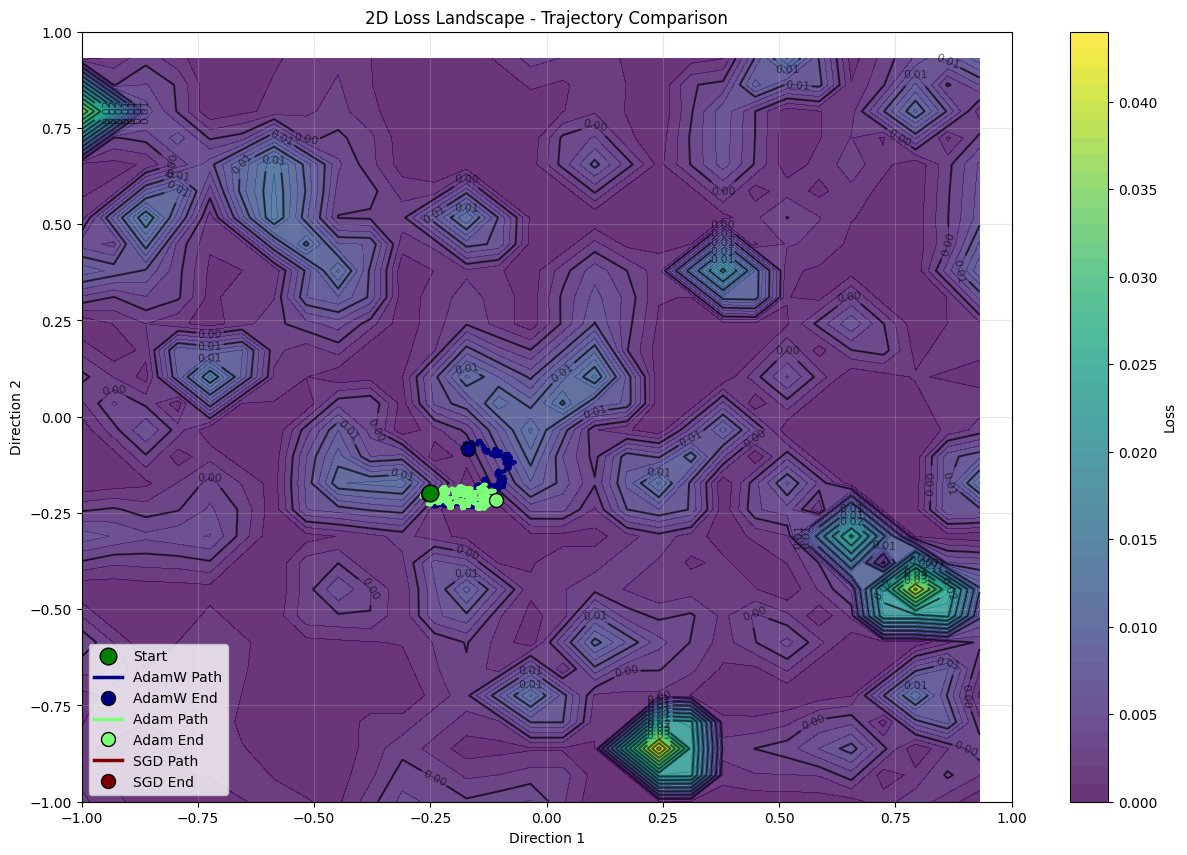

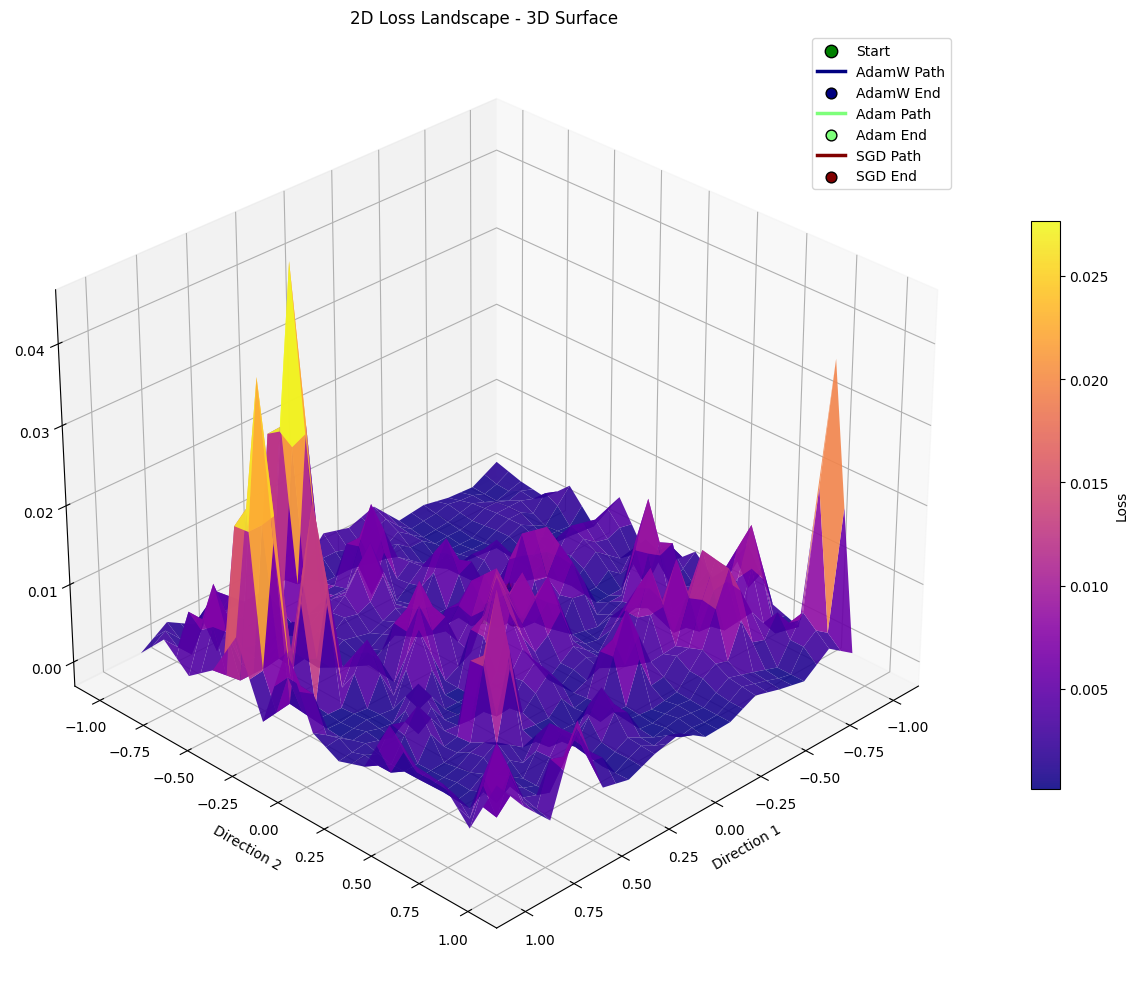

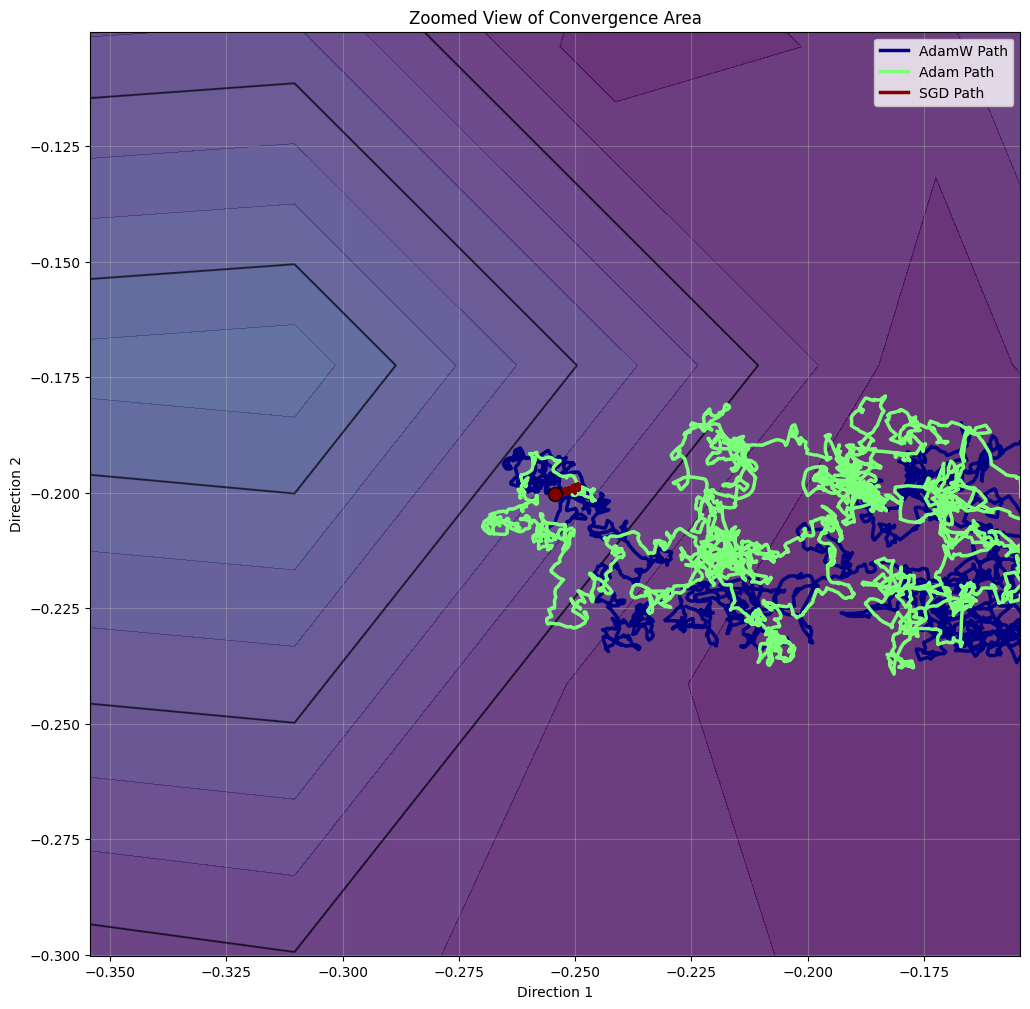

In [ ]:
demo_loss_landscape()

из-за того что у нас MNIST, то можно заметить что весь лосс варьируется от 0. до 0.04 и можно сказать, что у нас весь лосс это одно большое плато

Что можно сказать, так как наша реализация sgd самая базовая, то так как начальная инициализация оказалась на плато, очевидно, что никуда не сдвинулась точка SGD за 20 эпох, поттому что градиент очень маленький и в добавок он на маленький lr умножался.

Что касается Adam и AdamW они ну прям очень много двигались из-за того что опять же плато, градиенты маленткие, а в формуле там в знаменателе корень из суммы квадратов градиентов и так как значенатель оочень маленький вся дробь стновится очень большой, что давало ускорения на плоских местах потому что эти алгоритмы расчитаны на то, чтобы выбираться из плато. 

В данном случае будет лучше уменьшить на порядок lr для adam и на порядок увеличить у SGD


Также если проанализировать график лосса который был выше этих на нем заметно видно, sgd оказался лучше чем adam и adamw(если я конечно ничего не попутал в коде), то есть такие блуждания у Adam и AdamW не сильно им помогали. Можно сращу сделать вывод что для простых датасетов достаточно простых оптимизаторов.

In [ ]:
class LRScheduler:
    def __init__(self, optimizer):
        self.optimizer = optimizer
        self.base_lrs = [self.optimizer.lr]

    def step(self):
        pass

In [ ]:
import math

class LinearLR(LRScheduler):
    def __init__(
        self,
        optimizer,
        start_factor: float = 0.1,
        end_factor: float = 1.0,
        total_iters: int = 100
    ):
        super().__init__(optimizer)
        self.start_factor = start_factor
        self.end_factor = end_factor
        self.total_iters = total_iters
        self.count = 0

    def get_lr_multiplier(self):
        if self.count > self.total_iters:
            return self.end_factor
        return self.start_factor + (self.end_factor - self.start_factor) * (self.count / self.total_iters)

    def step(self):
        multiplier = self.get_lr_multiplier()
        self.optimizer.lr = self.base_lrs[0] * multiplier
        self.count += 1

class CosineAnnealing(LRScheduler):
    def __init__(
            self,
            optimizer,
            T_max: int = 20,
            eta_min: float = 0.01
        ):
        super().__init__(optimizer)
        self.T_max = T_max
        self.eta_min = eta_min
        self.count = 0

    def get_new_lr(self):
        if self.count > self.T_max:
            return self.eta_min
        cosine_part = math.cos(math.pi * self.count / self.T_max)
        return self.eta_min + 0.5 * (self.base_lrs[0] - self.eta_min) * (1 + cosine_part)

    def step(self):
        new_lr = self.get_new_lr()
        self.optimizer.lr = new_lr
        self.count += 1

In [ ]:
def training(model, train_loader, direction1, direction2, initial_params, optimizer_name, epochs=15):
    model = model.to("cuda")
    match optimizer_name:
        case "adam":
            optimizer = Adam(model.parameters())
        case "adamw":
            optimizer = AdamW(model.parameters())
        case "sgd":
            optimizer = SGD(model.parameters())
    scheduler = LinearLR(optimizer)
    criterion = nn.CrossEntropyLoss()
    direction1 = direction1.to("cuda")
    direction2 = direction2.to("cuda")
    initial_params = initial_params.to("cuda")
    step = 0
    trajectory = []
    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            data, target = data.to("cuda"), target.to("cuda")
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            scheduler.step()
            with torch.no_grad():
                theta_curr = parameters_to_vector(model.parameters()).detach()
                d = theta_curr - initial_params
                x = float(torch.dot(d, direction1).cpu().item())
                y = float(torch.dot(d, direction2).cpu().item())
                trajectory.append((x, y, step))
            step += 1
    return model, trajectory

def set_global_seed(seed):

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False



2D визуализация:


Rows: 100%|██████████| 15/15 [00:40<00:00,  2.70s/it]


Интерполяция пропущенных точек...


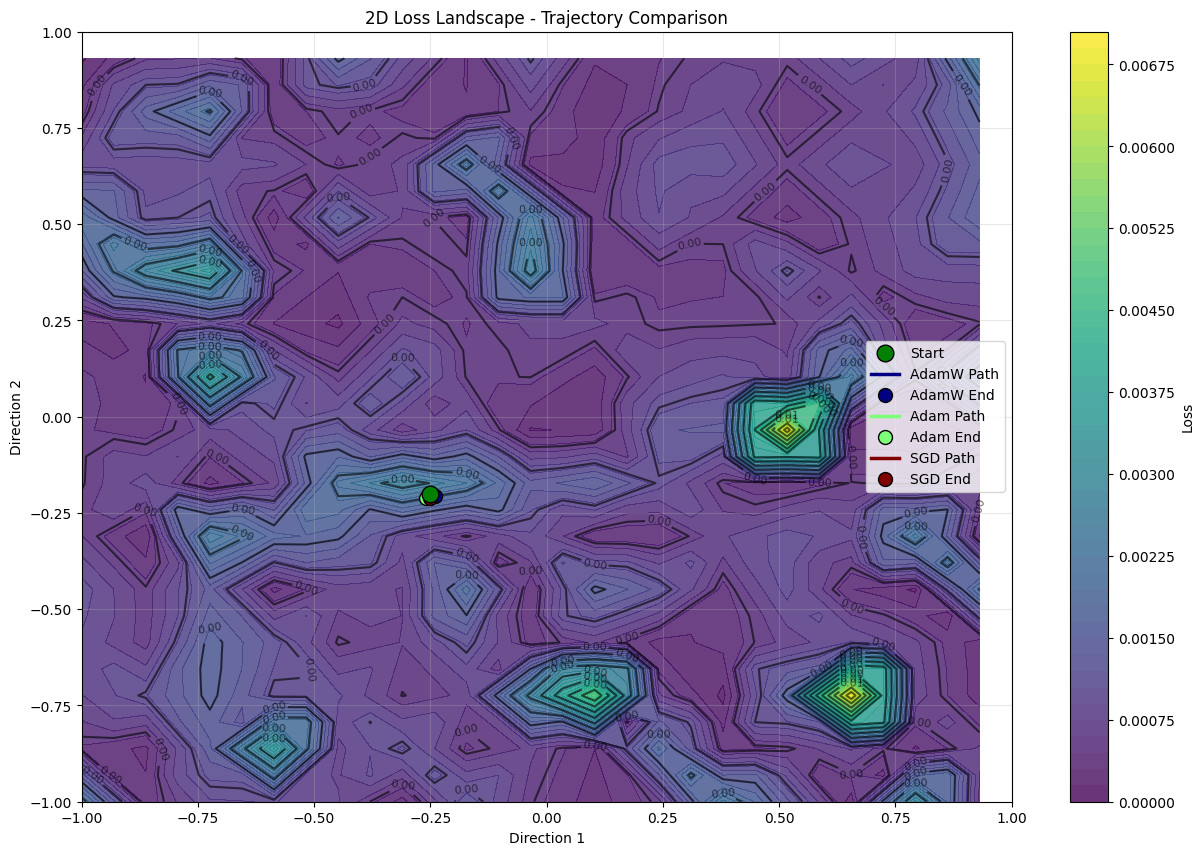

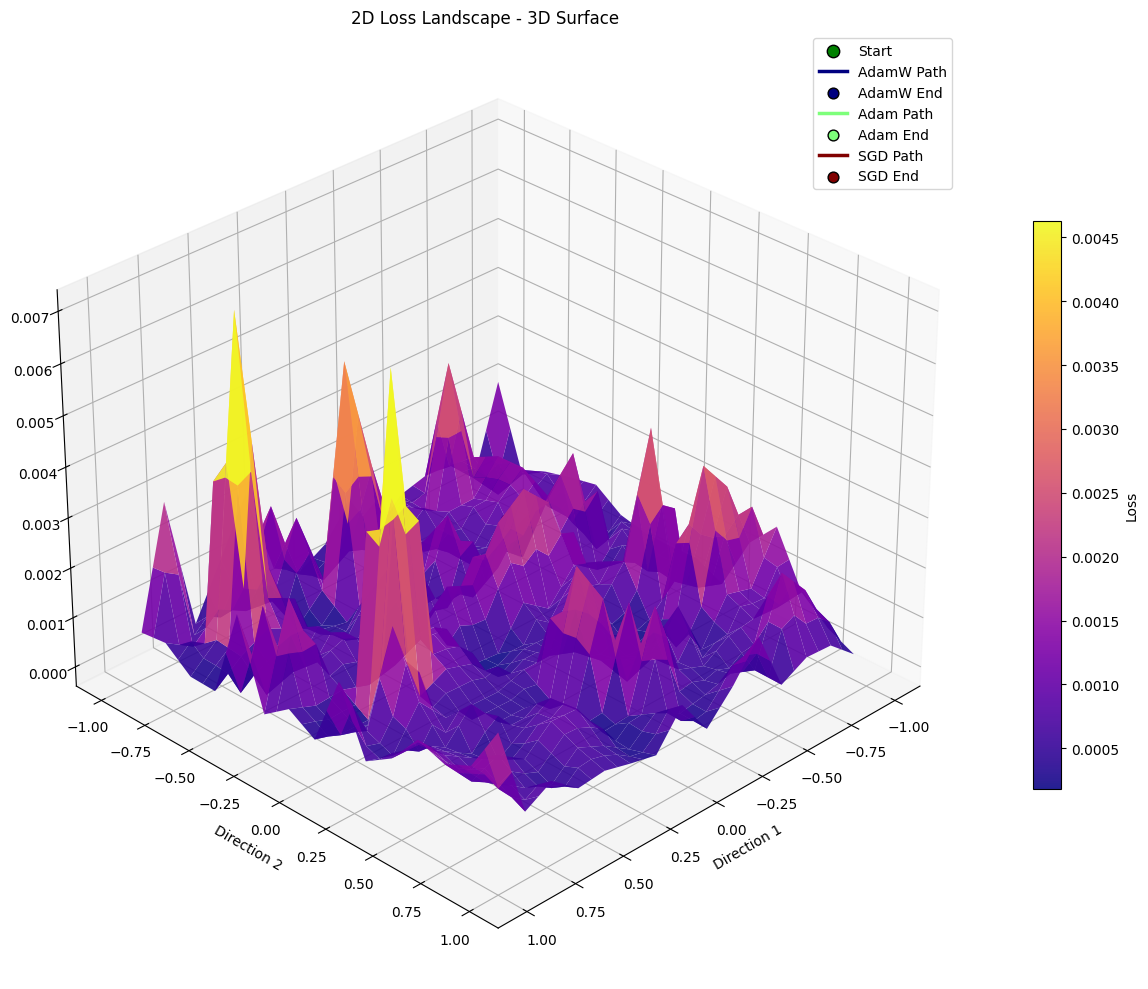

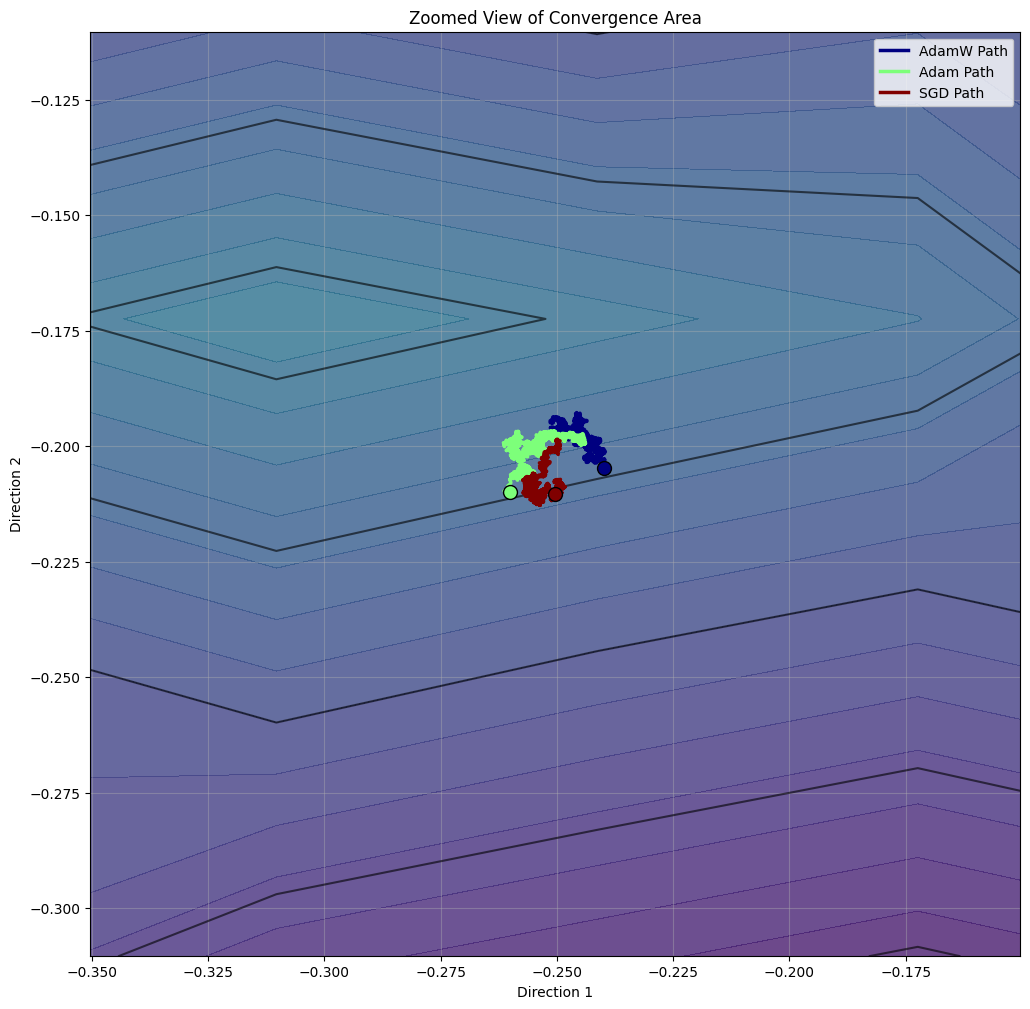

In [ ]:
demo_loss_landscape()

После прошлого раза я изменил lr на adam и adamw с 1е-3 до 1е-4, а у sgd c 1e-2 до 1е-1 и добавил LinearLR. Adam и adamW перестали слишком агрессивно двигаться потому что я уменьшил длину шага , видно что все три оптимизатора двигаются в одном направлении. Хотя на самом деле теперь Adam и AdamW практически не сдвинулись, нало было lr не сильно уменьшать и эпох побольше сделать. Также раньше sgd практически не сдвигался с начальной точки а сейчас виден сущесвтенный проход по сравнению с adam и adamW потому что я увиличился lr для sgd. Также скорее всего LinearLr сыграл роль стабилизатора.

In [ ]:
def training(model, train_loader, direction1, direction2, initial_params, optimizer_name, epochs=15):
    model = model.to("cuda")
    match optimizer_name:
        case "adam":
            optimizer = Adam(model.parameters())
        case "adamw":
            optimizer = AdamW(model.parameters())
        case "sgd":
            optimizer = SGD(model.parameters())
    scheduler = CosineAnnealing(optimizer)
    criterion = nn.CrossEntropyLoss()
    direction1 = direction1.to("cuda")
    direction2 = direction2.to("cuda")
    initial_params = initial_params.to("cuda")
    step = 0
    trajectory = []
    for epoch in range(epochs):
        model.train()
        for data, target in train_loader:
            data, target = data.to("cuda"), target.to("cuda")
            optimizer.zero_grad()
            output = model(data)
            loss = criterion(output, target)
            loss.backward()
            optimizer.step()
            scheduler.step()
            with torch.no_grad():
                theta_curr = parameters_to_vector(model.parameters()).detach()
                d = theta_curr - initial_params
                x = float(torch.dot(d, direction1).cpu().item())
                y = float(torch.dot(d, direction2).cpu().item())
                trajectory.append((x, y, step))
            step += 1
    return model, trajectory

def set_global_seed(seed):

    torch.manual_seed(seed)
    np.random.seed(seed)
    random.seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False



2D визуализация:


Rows: 100%|██████████| 15/15 [00:40<00:00,  2.73s/it]


Интерполяция пропущенных точек...


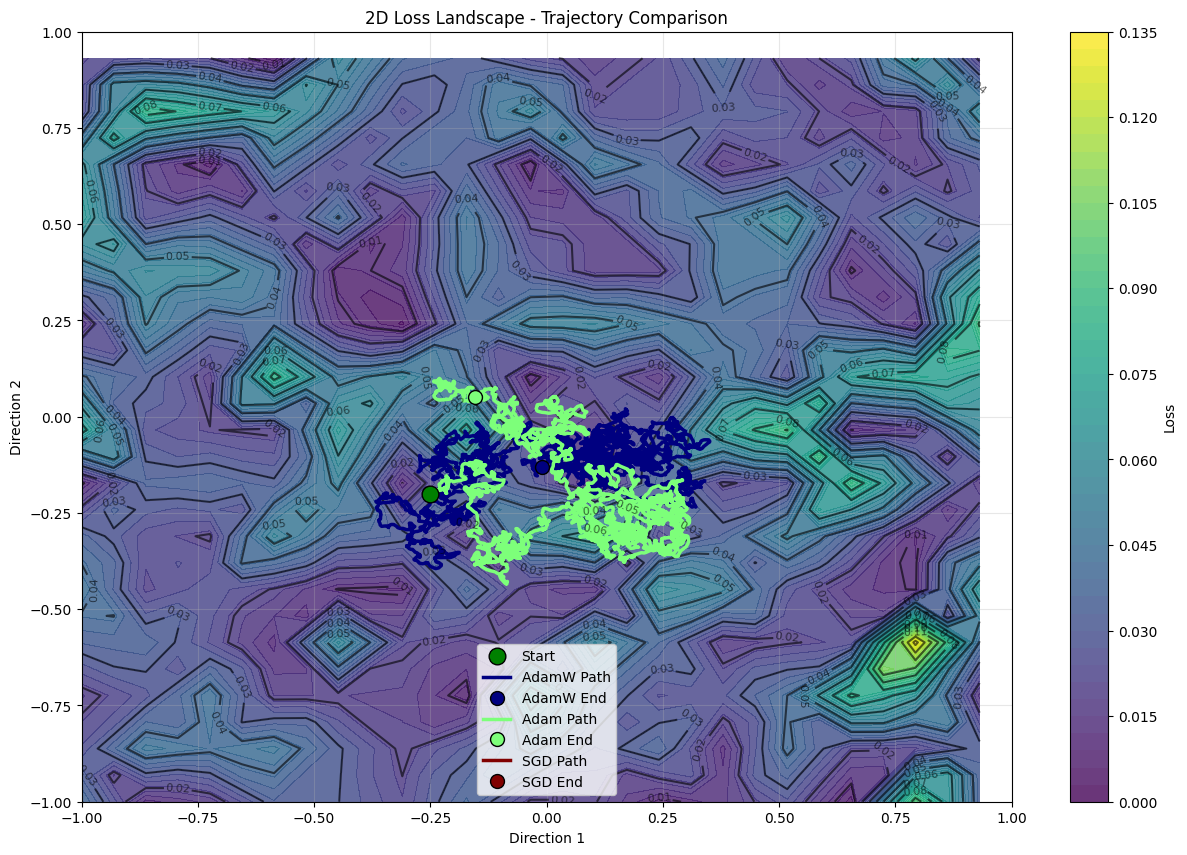

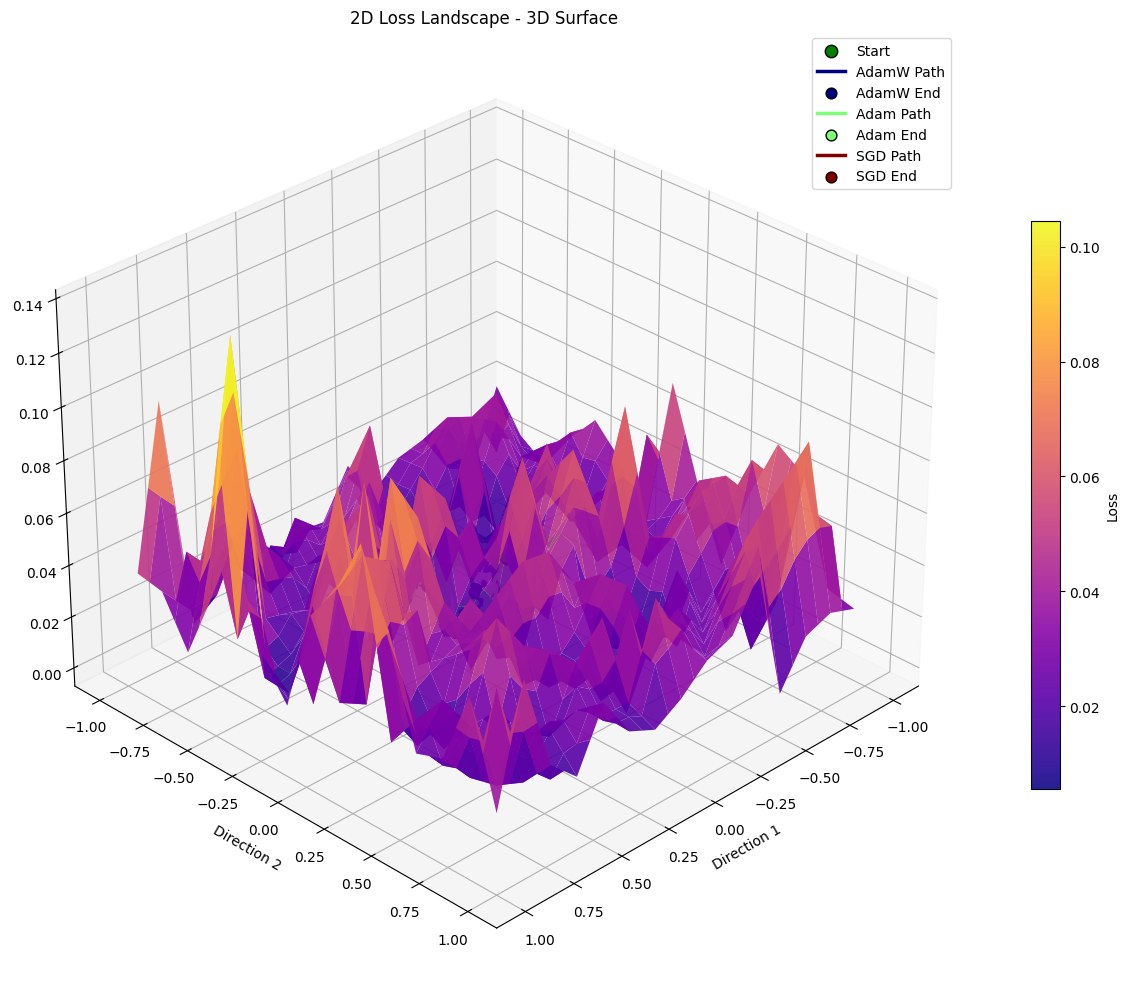

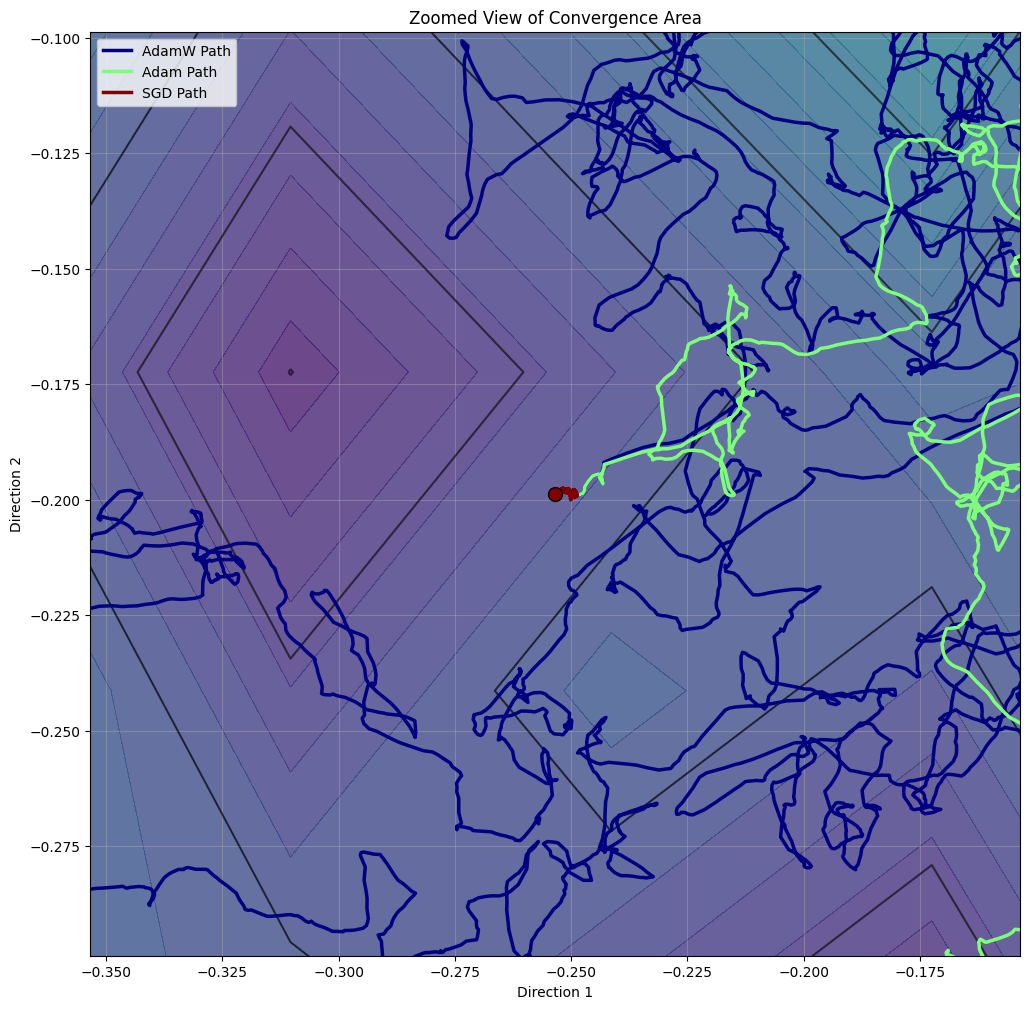

In [ ]:
demo_loss_landscape()

На этот раз мы видим более шумную поверхность и опять хаотичное движение adam и adamW как в первый раз , наверное потому что с CosineAnnealing на самых первых шагах используется высокий lr. Наверное еще потому что чтобы построить траекторию я использовал интерполяцию опорных точек для которых был посчитан лосс, но все равно это хаотичное движение.

#### Feedback (опционально)

Здесь вы можете оставить список опечаток из лекции или семинара:

- Your text here

Здесь вы можете оставить комментарии по лекции или семинару:

- Your text here